- Interactive Python Notebook. 
- The notebook must be functional and runnable (i.e., we must be able to import the .ipynyb without your support, and execute it).
- The results produced by the notebook should be self-explanatory.

# Compression codecs comparison analysis

Group members
- Laila Ibrahim
- Verica Dimitrova

In [2]:
# Importing relevant libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data from MinIO

In [3]:
# Importing the results.csv
minio = pd.read_csv("results - Copy.csv")
minio["codec"] = minio["codec"].fillna("None")

In [4]:
# Separating the results according to the size of the parquets
minio_S = minio[minio["size"] == "S"] 
minio_M = minio[minio["size"] == "M"]
minio_L = minio[minio["size"] == "L"]

## Size = S

In [5]:
# Computing the compression ratio
# Formula: 
# compression ratio = uncompressed size/ compressed size
uncompressed_S = minio_S.loc[minio_S["codec"] == "None", "stored_bytes_local"].values[0]
compressed_S_snappy = minio_S.loc[minio_S["codec"] == "snappy", "stored_bytes_local"].values[0]
compressed_S_zstd = minio_S.loc[minio_S["codec"] == "zstd", "stored_bytes_local"].values[0]
compressed_S_gzip = minio_S.loc[minio_S["codec"] == "gzip", "stored_bytes_local"].values[0]

ratio_S_snappy = uncompressed_S/compressed_S_snappy
print(ratio_S_snappy)

ratio_S_zstd = uncompressed_S/compressed_S_zstd
print(ratio_S_zstd)

ratio_S_gzip = uncompressed_S/compressed_S_gzip
print(ratio_S_gzip)

# the higher the compression ratio the better

1.1893032267777328
1.4120592936594472
1.4480165365345063


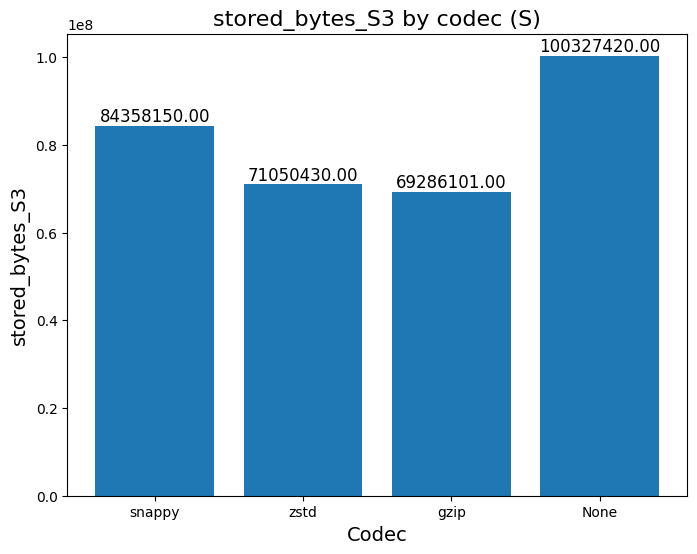

In [6]:
# Barplot of the stored bytes per codec for the files with size S

plt.figure(figsize=(8, 6))
barsS = plt.bar(minio_S["codec"], minio_S["stored_bytes_s3"]) # we can add color='color'  at the end to change it

# Annotating the bars
for bar in barsS:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=12)

# Adding labels and title
plt.xlabel("Codec", fontsize=14)
plt.ylabel("stored_bytes_S3", fontsize=14)
plt.title("stored_bytes_S3 by codec (S)", fontsize=16)
plt.show()


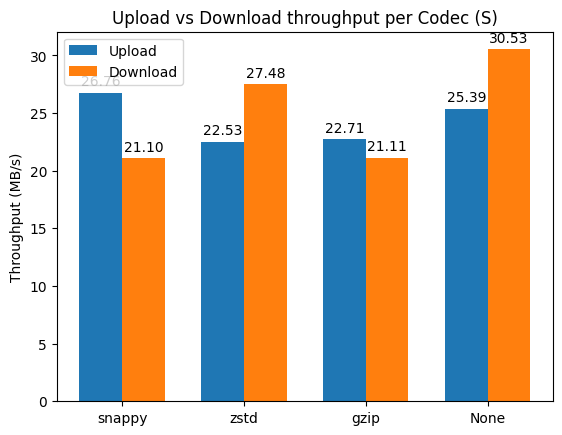

In [7]:
# Grouped barplot comparing the upload and download throughput per codec for the files with size S

x_S = np.arange(len(minio_S["codec"]))
width = 0.35

fig, ax = plt.subplots()
upload_sec_S = ax.bar(x_S-width/2, minio_S["upload_throughput"], width, label="Upload")
download_sec_S = ax.bar(x_S+width/2, minio_S["download_throughput"], width, label="Download")

ax.set_xticks(x_S)
ax.set_xticklabels(minio_S['codec'])
ax.set_ylabel("Throughput (MB/s)")
ax.set_title("Upload vs Download throughput per Codec (S)")
ax.legend()
ax.bar_label(upload_sec_S,fmt="%.2f", padding=3)
ax.bar_label(download_sec_S,fmt="%.2f", padding=3)

plt.show()

## Size = M

In [8]:
# Computing the compression ratio
# Formula: 
# compression ratio = uncompressed size/ compressed size
uncompressed_M = minio_M.loc[minio_M["codec"] == "None", "stored_bytes_local"].values[0]
compressed_M_snappy = minio_M.loc[minio_M["codec"] == "snappy", "stored_bytes_local"].values[0]
compressed_M_zstd = minio_M.loc[minio_M["codec"] == "zstd", "stored_bytes_local"].values[0]
compressed_M_gzip = minio_M.loc[minio_M["codec"] == "gzip", "stored_bytes_local"].values[0]

ratio_M_snappy = uncompressed_M/compressed_M_snappy
print(ratio_M_snappy)

ratio_M_zstd = uncompressed_M/compressed_M_zstd
print(ratio_M_zstd)

ratio_M_gzip = uncompressed_M/compressed_M_gzip
print(ratio_M_gzip)

# the higher the compression ratio the better

1.1893788599270734
1.4125082250240548
1.4484881223404287


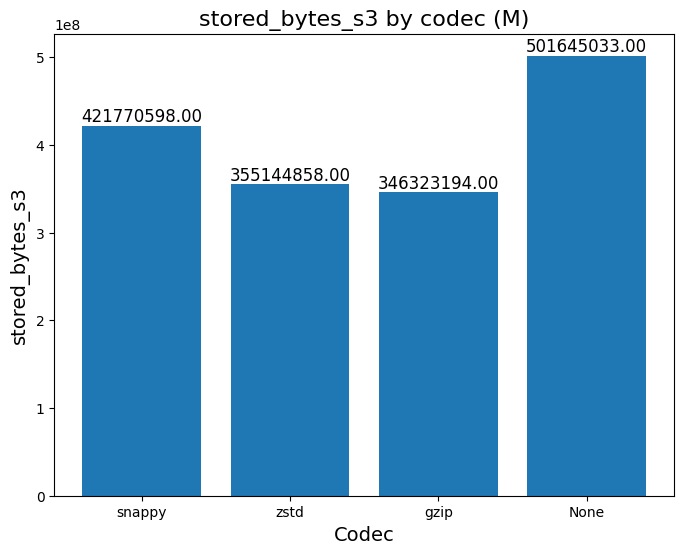

In [9]:
# Barplot of the stored bytes per codec for the files with size M

plt.figure(figsize=(8, 6))
barsM = plt.bar(minio_M["codec"], minio_M["stored_bytes_s3"]) # we can add color='color'  at the end to change it

# Annotating the bars
for bar in barsM:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=12)

# Adding labels and title
plt.xlabel("Codec", fontsize=14)
plt.ylabel("stored_bytes_s3", fontsize=14)
plt.title("stored_bytes_s3 by codec (M)", fontsize=16)
plt.show()

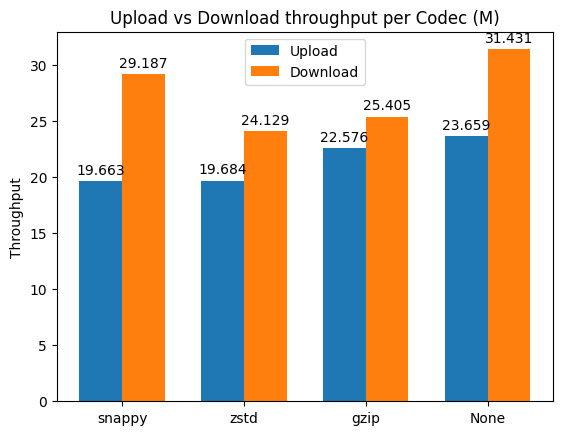

In [10]:
# Grouped barplot comparing the upload and download throughput per codec for the files with size M

x_M = np.arange(len(minio_M["codec"]))
width = 0.35

fig, ax = plt.subplots()
upload_sec_M = ax.bar(x_M-width/2, minio_M["upload_throughput"], width, label="Upload")
download_sec_M = ax.bar(x_M+width/2, minio_M["download_throughput"], width, label="Download")

ax.set_xticks(x_M)
ax.set_xticklabels(minio_M['codec'])
ax.set_ylabel("Throughput")
ax.set_title("Upload vs Download throughput per Codec (M)")
ax.legend()
ax.bar_label(upload_sec_M,fmt="%.3f", padding=3)
ax.bar_label(download_sec_M,fmt="%.3f", padding=3)

plt.show()

## Size = L

In [11]:
# Computing the compression ratio
# Formula: 
# compression ratio = uncompressed size/ compressed size
uncompressed_L = minio_L.loc[minio_L["codec"] == "None", "stored_bytes_local"].values[0]
compressed_L_snappy = minio_L.loc[minio_L["codec"] == "snappy", "stored_bytes_local"].values[0]
compressed_L_zstd = minio_L.loc[minio_L["codec"] == "zstd", "stored_bytes_local"].values[0]
compressed_L_gzip = minio_L.loc[minio_L["codec"] == "gzip", "stored_bytes_local"].values[0]

ratio_L_snappy = uncompressed_L/compressed_L_snappy
print(ratio_L_snappy)

ratio_L_zstd = uncompressed_L/compressed_L_zstd
print(ratio_L_zstd)

ratio_L_gzip = uncompressed_L/compressed_L_gzip
print(ratio_L_gzip)

# the higher the compression ratio the better

1.1893849218697448
1.4124308312999683
1.4483912784023496


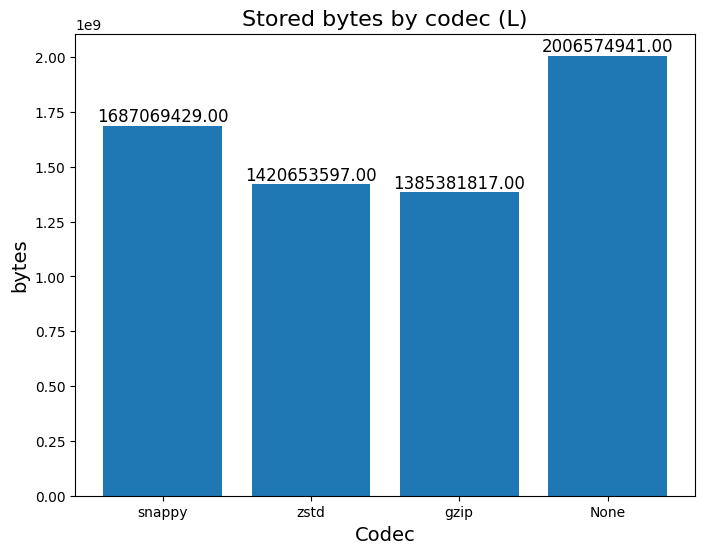

In [12]:
# Barplot of the stored bytes per codec for the files with size L

plt.figure(figsize=(8, 6))
barsL = plt.bar(minio_L["codec"], minio_L["stored_bytes_s3"]) # we can add color='color' at the end to change it

# Annotating the bars
for bar in barsL:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=12)

# Adding labels and title
plt.xlabel("Codec", fontsize=14)
plt.ylabel("bytes", fontsize=14)
plt.title("Stored bytes by codec (L)", fontsize=16)
plt.show()

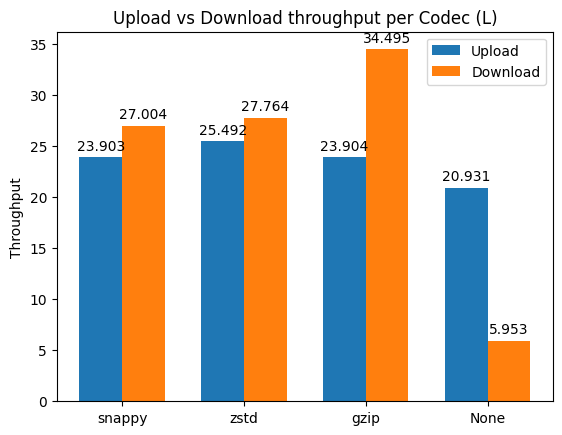

In [13]:
# Grouped barplot comparing the upload and download throughput per codec for the files with size L

x_L = np.arange(len(minio_L["codec"]))
width = 0.35

fig, ax = plt.subplots()
upload_sec_L = ax.bar(x_L-width/2, minio_L["upload_throughput"], width, label="Upload")
download_sec_L = ax.bar(x_L+width/2, minio_L["download_throughput"], width, label="Download")

ax.set_xticks(x_L)
ax.set_xticklabels(minio_L['codec'])
ax.set_ylabel("Throughput")
ax.set_title("Upload vs Download throughput per Codec (L)")
ax.legend()
ax.bar_label(upload_sec_L,fmt="%.3f", padding=3)
ax.bar_label(download_sec_L,fmt="%.3f", padding=3)

plt.show()

## Upload vs Download throughput per codec & per size

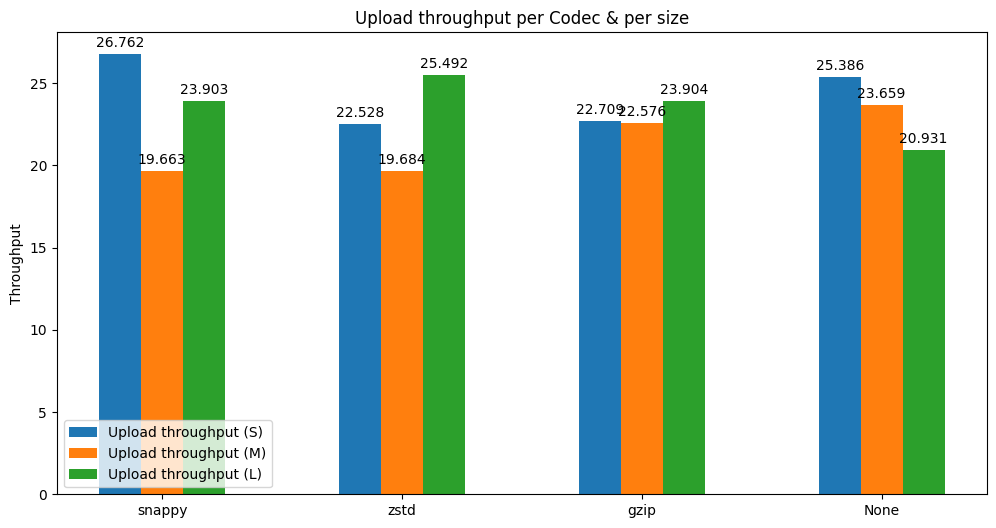

In [19]:
# Grouped barplot comparing the ... per codec and per file size

x_M = np.arange(len(minio_M["codec"]))*2 # doesn't matter if it's results_M, S or L since the codecs are the same.
# we *2 to increase the spacing between each group of bars (a group of bars = the bars of a codec)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
upload_sec_S = ax.bar(x_M-width, minio_S["upload_throughput"], width, label="Upload throughput (S)")
upload_sec_M = ax.bar(x_M, minio_M["upload_throughput"], width, label="Upload throughput (M)")
upload_sec_L = ax.bar(x_M+width, minio_L["upload_throughput"], width, label="Upload throughput (L)")

ax.set_xticks(x_M)
ax.set_xticklabels(minio_M['codec'])
ax.set_ylabel("Throughput")
ax.set_title("Upload throughput per Codec & per size")
ax.legend()
ax.bar_label(upload_sec_S,fmt="%.3f", padding=3)
ax.bar_label(upload_sec_M,fmt="%.3f", padding=3)
ax.bar_label(upload_sec_L,fmt="%.3f", padding=3)

plt.show()

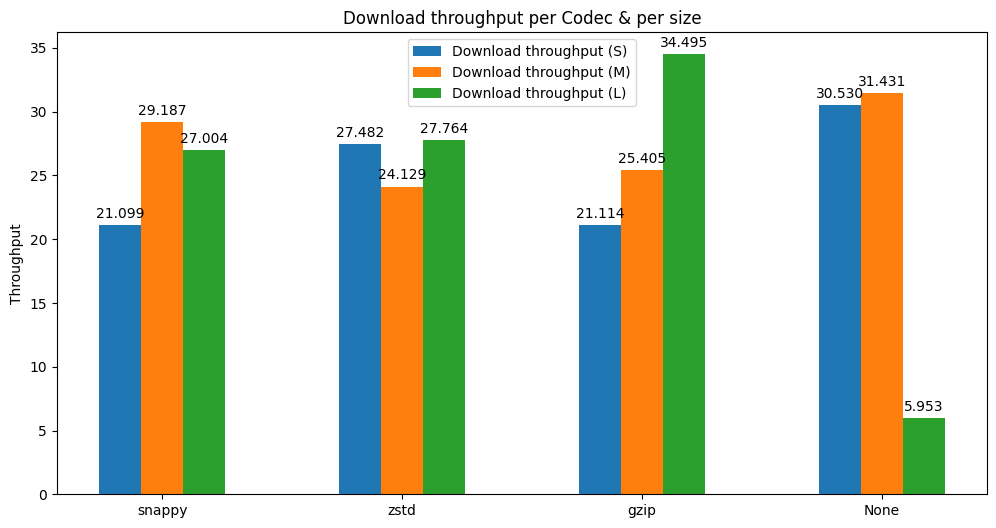

In [20]:
# Grouped barplot comparing the ... per codec and per file size

x_M = np.arange(len(minio_M["codec"]))*2 # doesn't matter if it's results_M, S or L since the codecs are the same.
# we *2 to increase the spacing between each group of bars (a group of bars = the bars of a codec)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
download_sec_S = ax.bar(x_M-width, minio_S["download_throughput"], width, label="Download throughput (S)")
download_sec_M = ax.bar(x_M, minio_M["download_throughput"], width, label="Download throughput (M)")
download_sec_L = ax.bar(x_M+width, minio_L["download_throughput"], width, label="Download throughput (L)")

ax.set_xticks(x_M)
ax.set_xticklabels(minio_M['codec'])
ax.set_ylabel("Throughput")
ax.set_title("Download throughput per Codec & per size")
ax.legend()
ax.bar_label(download_sec_S,fmt="%.3f", padding=3)
ax.bar_label(download_sec_M,fmt="%.3f", padding=3)
ax.bar_label(download_sec_L,fmt="%.3f", padding=3)

plt.show()

## Query runtime per codec & per size

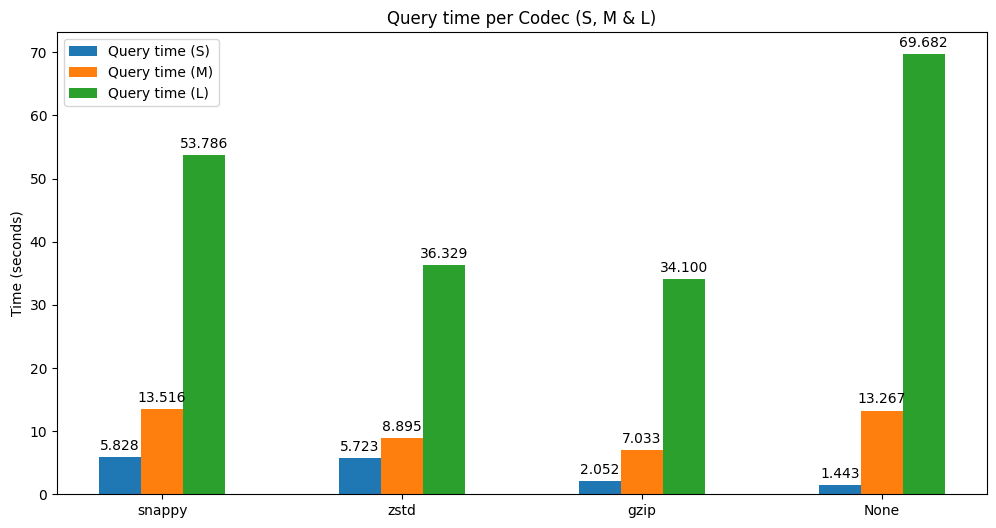

In [15]:
# Grouped barplot comparing the query runtime per codec and per file size

x_M = np.arange(len(minio_M["codec"]))*2 # doesn't matter if it's results_M, S or L since the codecs are the same.
# we *2 to increase the spacing between each group of bars (a group of bars = the bars of a codec)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
query_time_S = ax.bar(x_M-width, minio_S["query_time_seconds"], width, label="Query time (S)")
query_time_M = ax.bar(x_M, minio_M["query_time_seconds"], width, label="Query time (M)")
query_time_L = ax.bar(x_M+width, minio_L["query_time_seconds"], width, label="Query time (L)")

ax.set_xticks(x_M)
ax.set_xticklabels(minio_M['codec'])
ax.set_ylabel("Time (seconds)")
ax.set_title("Query time per Codec (S, M & L)")
ax.legend()
ax.bar_label(query_time_S,fmt="%.3f", padding=3)
ax.bar_label(query_time_M,fmt="%.3f", padding=3)
ax.bar_label(query_time_L,fmt="%.3f", padding=3)

plt.show()

# Data from Azure

In [16]:
# Importing the results_with_Azure.csv
azure = pd.read_csv("results_with_Azure.csv")
azure["codec"] = azure["codec"].fillna("None")

## Size = S

## Size = M

### Interactive testing

In [21]:
import ipywidgets as widgets
from IPython.display import display

codecs_order = ['None', 'snappy', 'zstd', 'gzip']
colors = {'S': '#378ADD', 'M': '#1D9E75', 'L' : '#0000FF'}

size_dd = widgets.Dropdown(options=['ALL', 'S', 'M','L'], description='Size:')

all_cb = widgets.Checkbox(value=True, description='All', indent=False)
codec_checkboxes = [widgets.Checkbox(value=True, description=c, indent=False) for c in codecs_order]

codec_box = widgets.VBox(
    [all_cb] + codec_checkboxes,
    layout=widgets.Layout(
        border='1px solid #ccc',
        padding='8px',
        width='150px',
        display='none'  # hidden by default
    )
)

toggle_btn = widgets.ToggleButton(
    value=False,
    description='Codecs ▾',
    layout=widgets.Layout(width='150px')
)

output = widgets.Output()
_updating = False

def toggle_dropdown(change):
    codec_box.layout.display = '' if change['new'] else 'none'

toggle_btn.observe(toggle_dropdown, names='value')

def on_all_change(change):
    global _updating
    if _updating:
        return
    _updating = True
    for cb in codec_checkboxes:
        cb.value = change['new']
    _updating = False
    update()

def on_codec_change(change):
    global _updating
    if _updating:
        return
    _updating = True
    all_cb.value = all(cb.value for cb in codec_checkboxes)
    _updating = False
    update()

all_cb.observe(on_all_change, names='value')
for cb in codec_checkboxes:
    cb.observe(on_codec_change, names='value')

def update(*args):
    output.clear_output(wait=True)
    size = size_dd.value
    selected_codecs = [c.description for c in codec_checkboxes if c.value]
    if not selected_codecs:
        return

    df = minio.copy()
    if size != 'ALL':
        df = df[df['size'] == size]
    df = df[df['codec'].isin(selected_codecs)]

    with output:
        fig, ax = plt.subplots(figsize=(8, 6))
        sizes = sorted(df['size'].unique())
        x = np.arange(len(selected_codecs))
        width = 0.6 / max(len(sizes), 1)

        for i, s in enumerate(sizes):
            sub = df[df['size'] == s].set_index('codec')
            vals = [sub.loc[c, 'query_time_seconds'] if c in sub.index else 0 for c in selected_codecs]
            bars = ax.bar(x + i*width - (len(sizes)-1)*width/2, vals, width, label=s, color=colors[s])
            ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(selected_codecs)
        ax.set_ylabel('Time (seconds)')
        ax.set_title('Query time per Codec')
        ax.legend()
        plt.tight_layout()
        plt.show()

size_dd.observe(update, names='value')

display(widgets.HBox([widgets.VBox([size_dd]), widgets.VBox([toggle_btn, codec_box])]))
display(output)
update()


Output()